In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [291]:
# Downloading the data (IMDb 1M+ instances...)

import kagglehub

# Download latest version
path = kagglehub.dataset_download("octopusteam/full-imdb-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/octopusteam/full-imdb-dataset/versions/14


In [292]:
# loading the data
data = pd.read_csv('data.csv')

**Dataset is too large... so we take only 30% of the avelaible data**

In [293]:
# data = data.sample(frac=0.3, random_state=42)

## Observing the Data...

In [294]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1031289 entries, 0 to 1031288
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   id             1031288 non-null  object 
 1   title          1031287 non-null  object 
 2   type           1031289 non-null  object 
 3   genres         930551 non-null   object 
 4   averageRating  440326 non-null   float64
 5   numVotes       440326 non-null   float64
 6   releaseYear    902503 non-null   float64
dtypes: float64(3), object(4)
memory usage: 55.1+ MB


In [295]:
data.head(5)

,id,title,type,genres,averageRating,numVotes,releaseYear
0,tt0000009,Miss Jerry,movie,Romance,5.4,215.0,1894.0
1,tt0000147,The Corbett-Fitzsimmons Fight,movie,"Documentary, News, Sport",5.2,539.0,1897.0
2,tt0000502,Bohemios,movie,NaN,4.4,18.0,1905.0
3,tt0000574,The Story of the Kelly Gang,movie,"Action, Adventure, Biography",6.0,941.0,1906.0
4,tt0000591,The Prodigal Son,movie,Drama,5.7,28.0,1907.0


In [296]:
movie_types = data['type']
movie_types.value_counts()

,count
type,
movie,699507
tvSeries,273615
tvMiniSeries,58167


In [297]:
data.describe()

,averageRating,numVotes,releaseYear
count,440326.000000,4.403260e+05,902503.000000
mean,6.362934,3.045408e+03,1998.301035
std,1.431581,3.267566e+04,27.050154
min,1.000000,5.000000e+00,1894.000000
25%,5.500000,1.700000e+01,1986.000000
50%,6.500000,5.200000e+01,2010.000000
75%,7.400000,2.600000e+02,2018.000000
max,10.000000,2.967877e+06,2031.000000


**Ploting the Data**

array([[<Axes: title={'center': 'averageRating'}>,
        <Axes: title={'center': 'numVotes'}>],
       [<Axes: title={'center': 'releaseYear'}>, <Axes: >]], dtype=object)

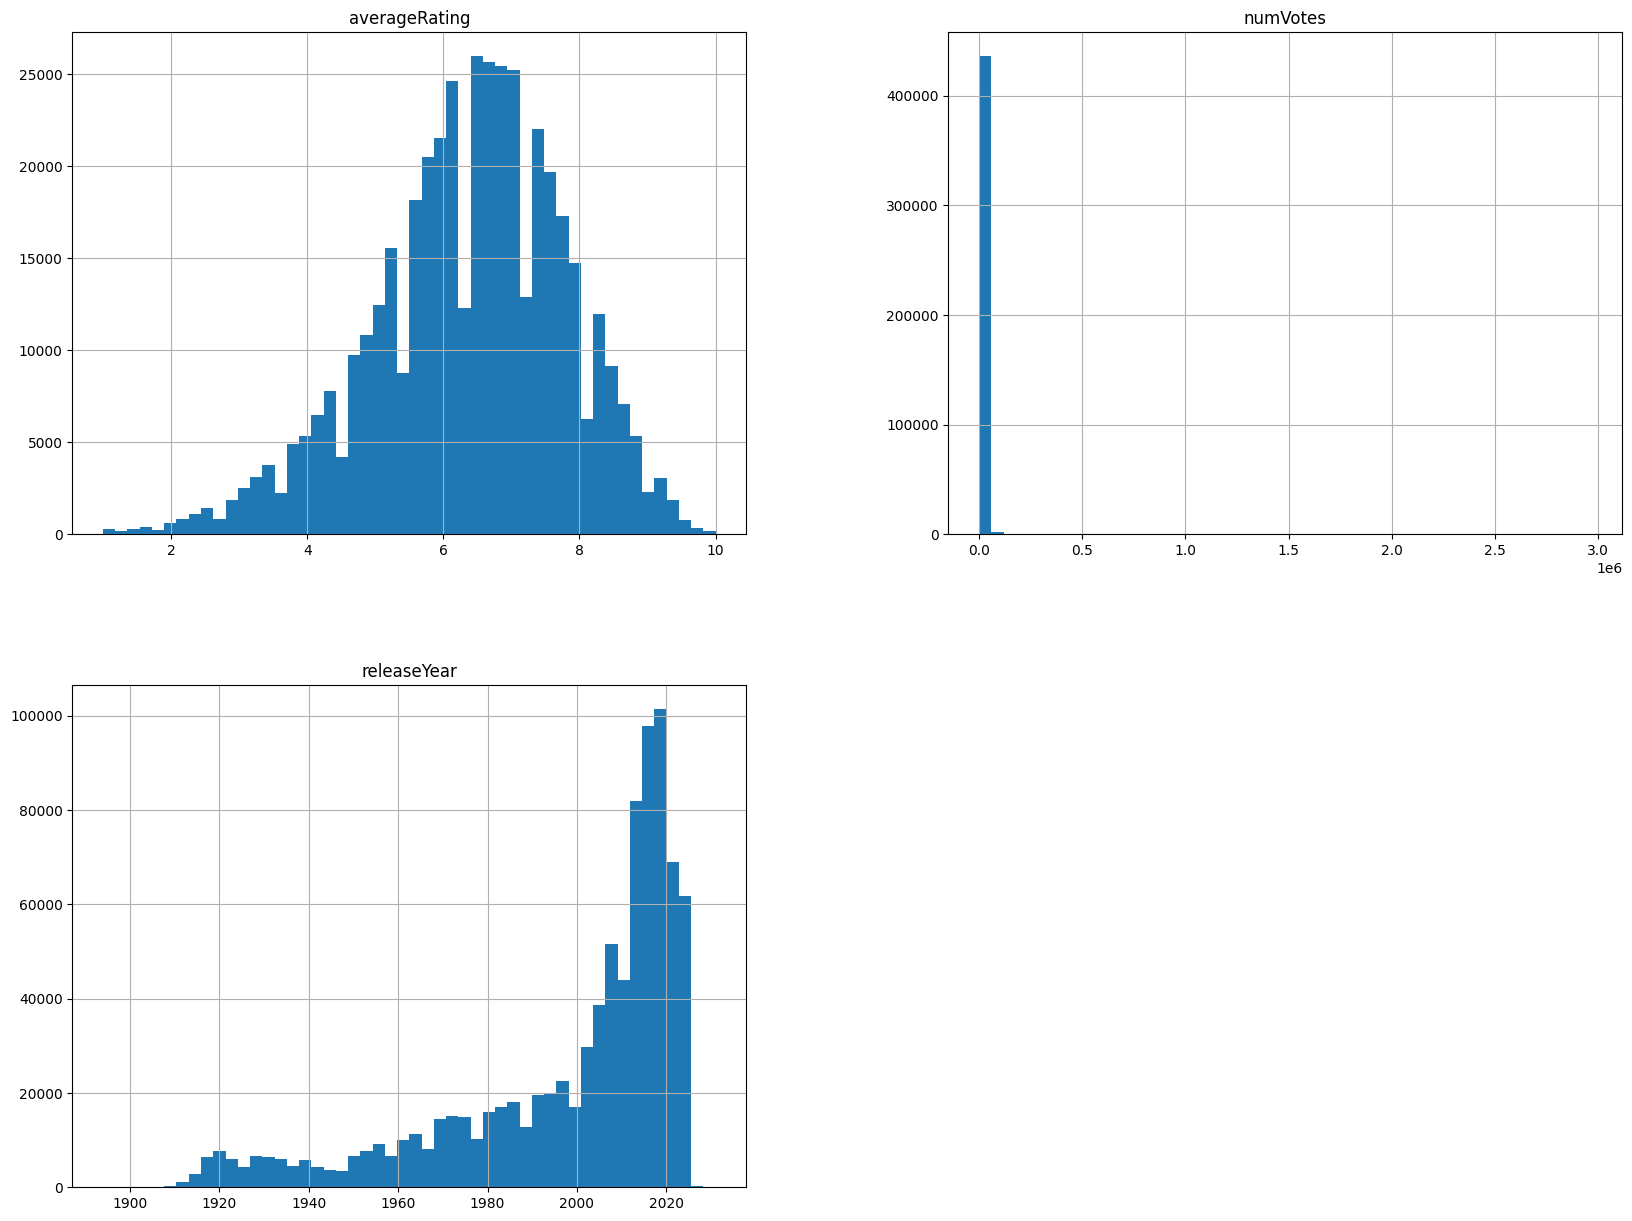

In [298]:
data.hist(bins=50, figsize=(20,15))

<Axes: xlabel='type'>

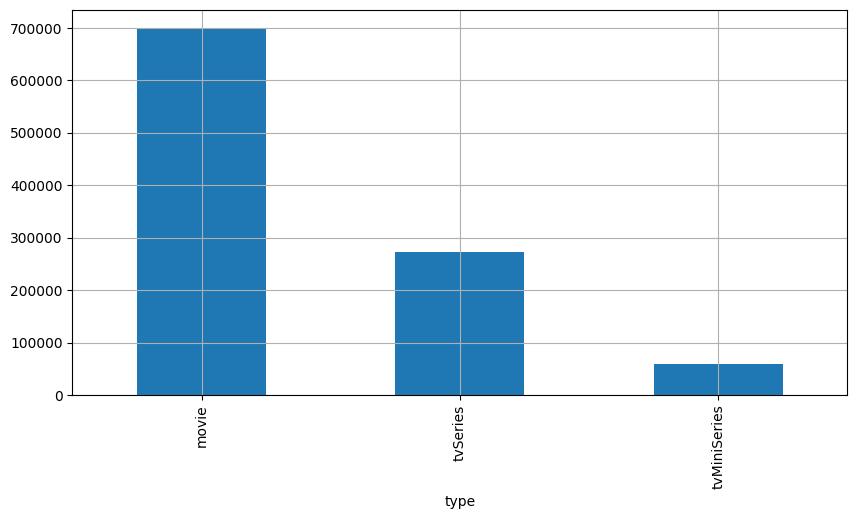

In [299]:
data['type'].value_counts().plot(kind='bar', grid=True, figsize=(10,5))

In [300]:
data['numVotes'].value_counts() > 500

,count
numVotes,
8.0,True
9.0,True
10.0,True
11.0,True
7.0,True
...,...
39629.0,False
93323.0,False
47667.0,False


In [301]:
# #grouping the voters according to count...

# data['numVotes_cat'] = pd.cut(data['numVotes']
#                                    , bins = [0, 1000, 5000, 10000, 20000, float('inf')]
#                                    , labels = ['Under 1k', '1k-5k', '5k-10k', '10k-20k', 'Over 20k'])

In [302]:
# data['numVotes_cat'].hist()

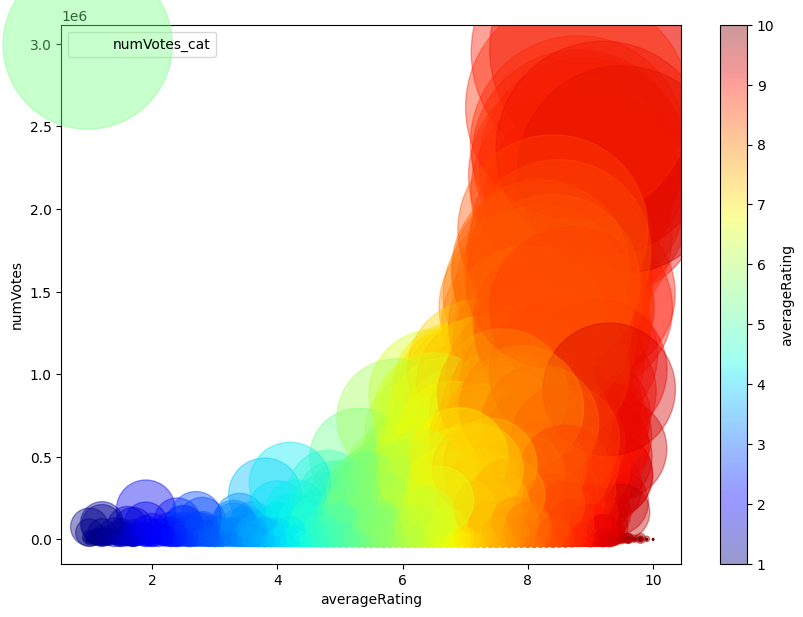

In [303]:
data.plot(kind = 'scatter', x = 'averageRating', y = 'numVotes', alpha = 0.4,
             s = data["numVotes"]/100, label = "numVotes_cat", figsize = (10, 7),
             c = "averageRating", cmap = plt.colormaps.get_cmap('jet'), colorbar = True)
plt.legend()
plt.show()

# well it seem use less since we are not getting any better info from the image...

**CoRelations**

In [304]:
corrMatrix = data.corr(numeric_only=True)
corrMatrix

,averageRating,numVotes,releaseYear
averageRating,1.000000,0.049675,0.098637
numVotes,0.049675,1.000000,0.019996
releaseYear,0.098637,0.019996,1.000000


#Cleaning the Data

In [305]:
data = data.drop(['id', 'title'], axis=1)

In [306]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1031289 entries, 0 to 1031288
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   type           1031289 non-null  object 
 1   genres         930551 non-null   object 
 2   averageRating  440326 non-null   float64
 3   numVotes       440326 non-null   float64
 4   releaseYear    902503 non-null   float64
dtypes: float64(3), object(2)
memory usage: 39.3+ MB


#**Handling the Missing values**

#Saperating features

In [307]:
numerical_features = ['numVotes', 'releaseYear']
categorical_features = ['type', 'genres']

In [308]:
numerical_data = data[['numVotes', 'releaseYear']]
numerical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1031289 entries, 0 to 1031288
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   numVotes     440326 non-null  float64
 1   releaseYear  902503 non-null  float64
dtypes: float64(2)
memory usage: 15.7 MB


In [309]:
categorical_data = data.drop(['averageRating', 'releaseYear', 'numVotes'], axis=1)
categorical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1031289 entries, 0 to 1031288
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   type    1031289 non-null  object
 1   genres  930551 non-null   object
dtypes: object(2)
memory usage: 15.7+ MB


In [310]:
# from sklearn.impute import SimpleImputer

# imputer_strings = SimpleImputer(strategy="most_frequent")
# cats = imputer_strings.fit_transform(categorical_data)

# imputer_numbers = SimpleImputer(strategy="median")
# nums = imputer_numbers.fit_transform(numerical_data)

In [311]:
# num_data = pd.DataFrame(nums, columns = numerical_data.columns)
# cat_data = pd.DataFrame(cats, columns = categorical_data.columns)

In [312]:
# imputer_numbers.statistics_

In [313]:
# imputer_strings.statistics_

In [314]:
# cat_data.info()

In [315]:
# num_data.info()

**Converting categorical values to numberic or matrix of numbers(encoding)**

In [316]:
# from sklearn.preprocessing import OneHotEncoder

# cat_encoder = OneHotEncoder()
# cat_1hot = cat_encoder.fit_transform(cat_data)

In [317]:
# cat_1hot.toarray()

**re-scaling the numeric data**

In [318]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# scaled_nums = scaler.fit_transform(num_data)

#We can also use pipeline to do the all above steps in few line

In [319]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer




# droping make more sence here...
data = data.dropna(subset=['averageRating'])

y = data['averageRating']
X = data.drop(['averageRating'], axis=1)

# if not droping missing values then do this...
# imputer = SimpleImputer(strategy='median')
# y = imputer.fit_transform(pd.DataFrame(y))

num_pipeline = make_pipeline(
    (SimpleImputer(strategy = 'median')),
    (StandardScaler())
    )

# num_data = num_pipeline.fit_transform(numerical_data)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy = 'most_frequent'),
    OneHotEncoder(sparse_output=False, handle_unknown='ignore')
)

# cat_data = cat_pipeline.fit_transform(categorical_data)
# target_scaler = StandardScaler()

In [320]:
from sklearn.compose import make_column_transformer

preprocessor = make_column_transformer(
        (num_pipeline, numerical_features), #numerical_data.columns),
        (cat_pipeline, categorical_features) #categorical_data.columns)
)
# processed_data = preprocessor.fit_transform(data)

In [321]:
# processed_data

In [322]:
# cat_features = preprocessor.transformers_[1][1].named_steps['onehotencoder'].get_feature_names_out(categorical_data.columns)
# feature_names = list(numerical_data.columns) + list(cat_features)

# processed_data_df = pd.DataFrame(processed_data, columns=feature_names) if not isinstance(processed_data, pd.DataFrame) else processed_data


#Spliting and Trianing:

In [323]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42)

In [324]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

model = make_pipeline(
    preprocessor,
    (DecisionTreeRegressor(max_depth=11)) # 11 , 12, 10 are the best hyperparameters...
    # (RandomForestRegressor(n_estimators=100, random_state=42, max_depth=11))
)

model.fit(X_train, y_train)

# RandomForestRegressor is better than the DecisionTreeRegressor but it take too much time...

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['numVotes', 'releaseYear']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['type', 'genres'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=11, random_state=42))])

#Predicting and Comparing

**Predictions**

In [325]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

**Comparing**

In [337]:
comparison_df = pd.DataFrame({
    'Original values': y_test[80:100].ravel().round(1),
    'Predicted Values': y_test_pred[80:100].ravel().round(1)
})

comparison_df

<ipython-input-337-97d2146265d5>:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  'Original values': y_test[80:100].ravel().round(1),


,Original values,Predicted Values
0,5.9,6.0
1,6.0,6.1
2,4.1,5.9
3,8.9,7.1
4,5.5,6.0
5,4.9,6.6
6,6.2,6.6
7,7.3,6.2
8,6.6,6.0
9,6.6,6.5


#Accuracy is low because we are predicting decimal values which hard to predict but our predictions are very close to the original ones...

In [327]:
accuracy = model.score(X_test, y_test)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.2117


#Different Error Rates

In [328]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, model.predict(X_test))
print(f'Mean Absolute Error: {mae:.3f}')

Mean Absolute Error: 0.970


In [329]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train R^2: {train_r2:.2f}")
print(f"Test R^2: {test_r2:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Train R^2: 0.22
Test R^2: 0.21
Test RMSE: 1.27
